# Demand Forecasting Model using PySpark

This notebook implements the final project requirements: ingestion, cleaning, exploratory analysis, feature engineering, Spark ML forecasting, optimization notes, and MLOps documentation for an e-commerce demand forecasting system.

## Team and Role Assignment

| Member | Role |
| --- | --- |
| Mahmoud Ahmed | Data Engineer (Ingestion & Storage) + Big Data Engineer (Optimization & Performance) |
| Mohamed ElSayed | Machine Learning Engineer (Model Development) |
| Abdelrahman Ayman | Data Analyst (Exploration & Insights) |
| Seif Ihab | MLOps Engineer (Deployment & Monitoring) |

Mahmoud owns two roles because the assignment has five roles but the team has four members. The two responsibilities are connected: reliable ingestion/storage decisions directly affect Spark partitioning, HDFS usage, and pipeline performance.

## Project Workflow

1. Download and ingest the public UCI Online Retail e-commerce dataset.
2. Clean transactional sales records using PySpark.
3. Store processed data in HDFS as partitioned Parquet.
4. Explore demand patterns and seasonality.
5. Build lag and calendar features for daily product demand.
6. Train and evaluate Spark ML forecasting models.
7. Save the best model and document deployment/monitoring steps.

In [7]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import re
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import GBTRegressor, LinearRegression, RandomForestRegressor
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models" / "best_demand_forecasting_model"
LOCAL_PREDICTIONS_DIR = OUTPUT_DIR / "best_model_predictions_parquet"
LOCAL_JDK_DIR = next((BASE_DIR / ".jdk").glob("jdk-21*"), None)
HDFS_URI = "hdfs://localhost:9000"
HDFS_PROJECT_DIR = "/demand_forecasting"
HDFS_PROCESSED_PATH = f"{HDFS_URI}{HDFS_PROJECT_DIR}/processed/clean_online_retail_parquet"
HDFS_PREDICTIONS_PATH = f"{HDFS_URI}{HDFS_PROJECT_DIR}/outputs/best_model_predictions_parquet"

for directory in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, MODEL_DIR.parent]:
    directory.mkdir(parents=True, exist_ok=True)

def spark_local_uri(path: Path) -> str:
    """Build a Spark-compatible local URI without escaping spaces in folder names."""
    return "file://" + str(path.resolve())


DATASET_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
XLSX_PATH = RAW_DIR / "Online Retail.xlsx"
CSV_PATH = RAW_DIR / "online_retail.csv"
CSV_URI = spark_local_uri(CSV_PATH)
MODEL_URI = spark_local_uri(MODEL_DIR)
LOCAL_PREDICTIONS_URI = spark_local_uri(LOCAL_PREDICTIONS_DIR)
RANDOM_SEED = 42

### Local Java Requirement

Apache Spark runs on the JVM. Use Java 17 or Java 21 for this project. Java 26 is currently too new for the installed Spark runtime and can fail during Spark startup.

In [8]:
if LOCAL_JDK_DIR and (LOCAL_JDK_DIR / "bin" / "java").exists():
    os.environ["JAVA_HOME"] = str(LOCAL_JDK_DIR)
    os.environ["PATH"] = f"{LOCAL_JDK_DIR / 'bin'}:{os.environ['PATH']}"
    print(f"Using project-local Java: {LOCAL_JDK_DIR}")

java_version_output = subprocess.run(["java", "-version"], capture_output=True, text=True).stderr
print(java_version_output.splitlines()[0] if java_version_output else "Java version not found")

match = re.search(r'"(\d+)', java_version_output)
if match:
    java_major = int(match.group(1))
    if java_major > 21:
        raise RuntimeError(
            f"Detected Java {java_major}. Install/select Java 17 or 21, or run the provided local JDK setup. "
            "Spark cannot start with Java 26."
        )

Using project-local Java: /home/morgma/Home/Collage/Distributed Data Analytics/Final Project/.jdk/jdk-21.0.11+10
openjdk version "21.0.11" 2026-04-21 LTS


In [9]:
spark = (
    SparkSession.builder
    .appName("PySpark Demand Forecasting Final Project")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.hadoop.fs.defaultFS", HDFS_URI)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark.version

'4.1.1'

## 1. Data Engineer: Ingestion and Storage

The original file is Excel, so the notebook downloads it once, converts it to CSV with pandas, and then uses Spark for the actual distributed-style ingestion, cleaning, aggregation, and modeling pipeline. Start the local HDFS services before running this notebook so Spark can write processed data to `hdfs://localhost:9000/demand_forecasting`.

In [10]:
if not XLSX_PATH.exists():
    print(f"Downloading dataset to {XLSX_PATH} ...")
    urlretrieve(DATASET_URL, XLSX_PATH)

if not CSV_PATH.exists():
    print(f"Converting Excel dataset to CSV at {CSV_PATH} ...")
    retail_pd = pd.read_excel(XLSX_PATH, engine="openpyxl")
    retail_pd.to_csv(CSV_PATH, index=False)

# Spark's default filesystem is HDFS in this project, so local files must use file:// URIs.
raw_df = spark.read.csv(CSV_URI, header=True, inferSchema=True)
raw_df.printSchema()
raw_df.show(5, truncate=False)

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|InvoiceDate        |UnitPrice|CustomerID|Country       |
+---------+---------+-----------------------------------+--------+-------------------+---------+----------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6       |2010-12-01 08:26:00|2.55     |17850.0   |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6       |2010-12-01 08:26:00|3.39     |17850.0   |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT 

### Cleaning Rules

- Remove cancelled invoices, which start with `C`.
- Keep only positive quantities and prices.
- Drop rows without product, description, country, or timestamp.
- Convert invoice timestamps to Spark timestamp/date fields.
- Add revenue and calendar columns for downstream analysis.

In [11]:
clean_df = (
    raw_df
    .withColumn("InvoiceNo", F.col("InvoiceNo").cast("string"))
    .withColumn("StockCode", F.col("StockCode").cast("string"))
    .withColumn("InvoiceTimestamp", F.to_timestamp("InvoiceDate"))
    .withColumn("Quantity", F.col("Quantity").cast("double"))
    .withColumn("UnitPrice", F.col("UnitPrice").cast("double"))
    .filter(~F.col("InvoiceNo").startswith("C"))
    .filter(F.col("Quantity") > 0)
    .filter(F.col("UnitPrice") > 0)
    .dropna(subset=["StockCode", "Description", "Country", "InvoiceTimestamp"])
    .withColumn("OrderDate", F.to_date("InvoiceTimestamp"))
    .withColumn("Revenue", F.round(F.col("Quantity") * F.col("UnitPrice"), 2))
    .withColumn("Year", F.year("OrderDate"))
    .withColumn("Month", F.month("OrderDate"))
    .withColumn("YearMonth", F.date_format("OrderDate", "yyyy-MM"))
)

print(f"Raw rows: {raw_df.count():,}")
print(f"Clean rows: {clean_df.count():,}")
clean_df.select("InvoiceNo", "StockCode", "Description", "Quantity", "OrderDate", "Revenue", "Country").show(10, truncate=False)

Raw rows: 541,909
Clean rows: 530,104
+---------+---------+-----------------------------------+--------+----------+-------+--------------+
|InvoiceNo|StockCode|Description                        |Quantity|OrderDate |Revenue|Country       |
+---------+---------+-----------------------------------+--------+----------+-------+--------------+
|536365   |85123A   |WHITE HANGING HEART T-LIGHT HOLDER |6.0     |2010-12-01|15.3   |United Kingdom|
|536365   |71053    |WHITE METAL LANTERN                |6.0     |2010-12-01|20.34  |United Kingdom|
|536365   |84406B   |CREAM CUPID HEARTS COAT HANGER     |8.0     |2010-12-01|22.0   |United Kingdom|
|536365   |84029G   |KNITTED UNION FLAG HOT WATER BOTTLE|6.0     |2010-12-01|20.34  |United Kingdom|
|536365   |84029E   |RED WOOLLY HOTTIE WHITE HEART.     |6.0     |2010-12-01|20.34  |United Kingdom|
|536365   |22752    |SET 7 BABUSHKA NESTING BOXES       |2.0     |2010-12-01|15.3   |United Kingdom|
|536365   |21730    |GLASS STAR FROSTED T-LIGHT HOLDE

In [12]:
processed_sales_path = HDFS_PROCESSED_PATH

(
    clean_df
    .repartition(8, "YearMonth")
    .write
    .mode("overwrite")
    .partitionBy("YearMonth")
    .parquet(processed_sales_path)
)

sales_df = spark.read.parquet(processed_sales_path).cache()
sales_df.count(), sales_df.rdd.getNumPartitions()

(530104, 13)

## 2. Data Analyst: Exploration and Insights

EDA focuses on business questions that matter for demand planning: which products sell most, which markets drive revenue, and whether demand changes by month or weekday.

In [13]:
sales_df.createOrReplaceTempView("sales")

top_products = spark.sql("""
    SELECT StockCode, first(Description) AS Description,
           SUM(Quantity) AS TotalQuantity, ROUND(SUM(Revenue), 2) AS TotalRevenue
    FROM sales
    GROUP BY StockCode
    ORDER BY TotalQuantity DESC
    LIMIT 10
""").toPandas()

top_countries = spark.sql("""
    SELECT Country, SUM(Quantity) AS TotalQuantity, ROUND(SUM(Revenue), 2) AS TotalRevenue
    FROM sales
    GROUP BY Country
    ORDER BY TotalRevenue DESC
    LIMIT 10
""").toPandas()

monthly_demand = spark.sql("""
    SELECT YearMonth, SUM(Quantity) AS TotalQuantity, ROUND(SUM(Revenue), 2) AS TotalRevenue
    FROM sales
    GROUP BY YearMonth
    ORDER BY YearMonth
""").toPandas()

display(top_products)
display(top_countries)
display(monthly_demand.head())

,StockCode,Description,TotalQuantity,TotalRevenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995.0,168469.60
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033.0,81700.92
2,22197,POPCORN HOLDER,56921.0,51354.02
3,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047.0,13841.85
4,85099B,JUMBO BAG RED RETROSPOT,48474.0,94340.05
5,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37660.0,104518.80
6,84879,ASSORTED COLOUR BIRD ORNAMENT,36461.0,59094.93
7,21212,PACK OF 72 RETROSPOT CAKE CASES,36419.0,21259.10
8,23084,RABBIT NIGHT LIGHT,30788.0,66964.99
9,22492,MINI PAINT SET VINTAGE,26633.0,16937.82


,Country,TotalQuantity,TotalRevenue
0,United Kingdom,4662390.0,9025222.08
1,Netherlands,200361.0,285446.34
2,EIRE,147173.0,283453.96
3,Germany,119261.0,228867.14
4,France,112103.0,209715.11
5,Australia,83901.0,138521.31
6,Spain,27940.0,61577.11
7,Switzerland,30629.0,57089.90
8,Belgium,23237.0,41196.34
9,Sweden,36083.0,38378.33


,YearMonth,TotalQuantity,TotalRevenue
0,2010-12,359239.0,823746.14
1,2011-01,387785.0,691364.56
2,2011-02,283555.0,523631.89
3,2011-03,377526.0,717639.36
4,2011-04,308815.0,537808.62


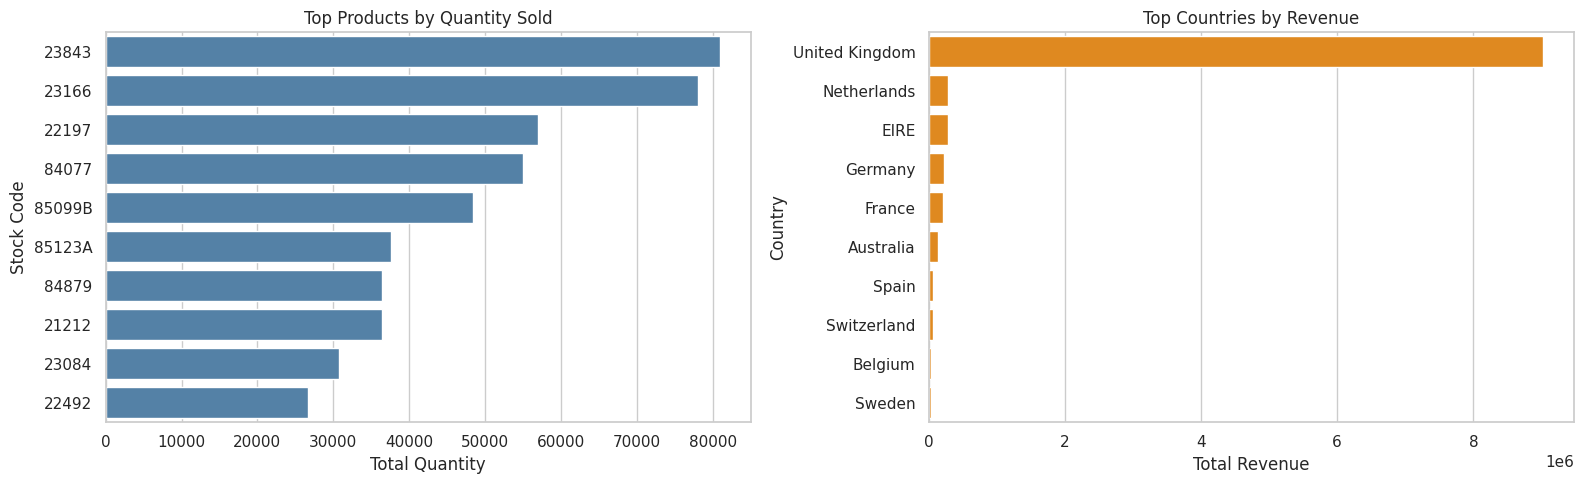

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_products, y="StockCode", x="TotalQuantity", ax=axes[0], color="steelblue")
axes[0].set_title("Top Products by Quantity Sold")
axes[0].set_xlabel("Total Quantity")
axes[0].set_ylabel("Stock Code")

sns.barplot(data=top_countries, y="Country", x="TotalRevenue", ax=axes[1], color="darkorange")
axes[1].set_title("Top Countries by Revenue")
axes[1].set_xlabel("Total Revenue")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_products_and_countries.png", dpi=150, bbox_inches="tight")
plt.show()

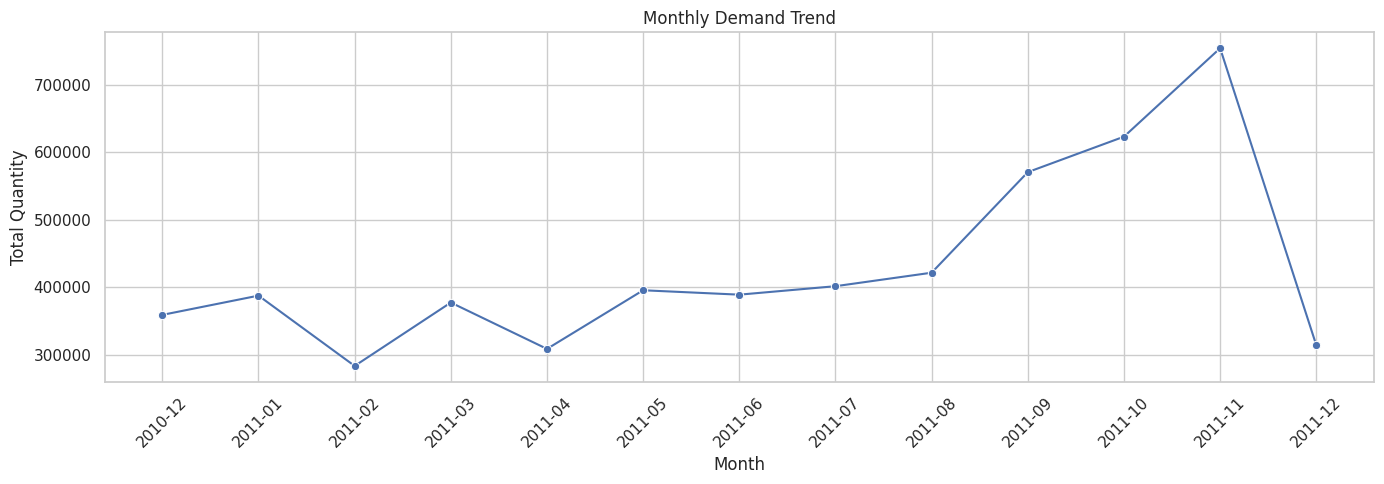

In [15]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_demand, x="YearMonth", y="TotalQuantity", marker="o")
plt.xticks(rotation=45) 
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "monthly_demand_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Machine Learning Engineer: Feature Engineering and Models

The forecasting target is daily product demand. Features use only calendar values and historical demand values. Same-day totals are not used as predictors, which prevents target leakage.

In [16]:
top_product_codes = [row.StockCode for row in sales_df.groupBy("StockCode").agg(F.sum("Quantity").alias("qty")).orderBy(F.desc("qty")).limit(150).collect()]

daily_product_df = (
    sales_df
    .filter(F.col("StockCode").isin(top_product_codes))
    .groupBy("OrderDate", "StockCode", "Country")
    .agg(
        F.sum("Quantity").alias("TotalQuantity"),
        F.sum("Revenue").alias("TotalRevenue"),
        F.countDistinct("InvoiceNo").alias("InvoiceCount")
    )
    .withColumn("DayOfWeek", F.dayofweek("OrderDate"))
    .withColumn("Month", F.month("OrderDate"))
    .withColumn("IsWeekend", F.when(F.col("DayOfWeek").isin([1, 7]), 1.0).otherwise(0.0))
    .withColumn("DayIndex", F.datediff("OrderDate", F.lit("2010-01-01")))
)

history_window = Window.partitionBy("StockCode", "Country").orderBy("OrderDate")
rolling_7_window = history_window.rowsBetween(-7, -1)

feature_df = (
    daily_product_df
    .withColumn("Lag1Quantity", F.lag("TotalQuantity", 1).over(history_window))
    .withColumn("Lag7Quantity", F.lag("TotalQuantity", 7).over(history_window))
    .withColumn("Rolling7AvgQuantity", F.avg("TotalQuantity").over(rolling_7_window))
    .dropna(subset=["Lag1Quantity", "Lag7Quantity", "Rolling7AvgQuantity"])
    .cache()
)

print(f"Modeling rows: {feature_df.count():,}")
feature_df.orderBy("StockCode", "Country", "OrderDate").show(10, truncate=False)

Modeling rows: 34,868
+----------+---------+--------------+-------------+-----------------+------------+---------+-----+---------+--------+------------+------------+-------------------+
|OrderDate |StockCode|Country       |TotalQuantity|TotalRevenue     |InvoiceCount|DayOfWeek|Month|IsWeekend|DayIndex|Lag1Quantity|Lag7Quantity|Rolling7AvgQuantity|
+----------+---------+--------------+-------------+-----------------+------------+---------+-----+---------+--------+------------+------------+-------------------+
|2011-09-04|15036    |Germany       |12.0         |9.96             |1           |1        |9    |1.0      |611     |300.0       |24.0        |164.57142857142858 |
|2010-12-13|15036    |United Kingdom|4.0          |5.12             |1           |2        |12   |0.0      |346     |3.0         |48.0        |13.714285714285714 |
|2010-12-14|15036    |United Kingdom|12.0         |9.0              |1           |3        |12   |0.0      |347     |4.0         |15.0        |7.4285714285714

In [17]:
feature_columns = [
    "StockCodeIndex",
    "CountryIndex",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "DayIndex",
    "Lag1Quantity",
    "Lag7Quantity",
    "Rolling7AvgQuantity",
    "InvoiceCount",
]

stock_indexer = StringIndexer(inputCol="StockCode", outputCol="StockCodeIndex", handleInvalid="keep")
country_indexer = StringIndexer(inputCol="Country", outputCol="CountryIndex", handleInvalid="keep")
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features", handleInvalid="keep")

cutoff_day = feature_df.approxQuantile("DayIndex", [0.8], 0.0)[0]
train_df = feature_df.filter(F.col("DayIndex") <= cutoff_day)
test_df = feature_df.filter(F.col("DayIndex") > cutoff_day)

print(f"Training rows: {train_df.count():,}")
print(f"Testing rows: {test_df.count():,}")
print(f"Time split cutoff day index: {cutoff_day}")

Training rows: 27,977
Testing rows: 6,891
Time split cutoff day index: 655.0


In [18]:
models = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="TotalQuantity", maxIter=50, regParam=0.1),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="TotalQuantity", numTrees=30, maxDepth=6, maxBins=512, seed=RANDOM_SEED),
    "Gradient Boosted Trees": GBTRegressor(featuresCol="features", labelCol="TotalQuantity", maxIter=25, maxDepth=5, maxBins=512, seed=RANDOM_SEED),
}

evaluators = {
    "RMSE": RegressionEvaluator(labelCol="TotalQuantity", predictionCol="prediction", metricName="rmse"),
    "MAE": RegressionEvaluator(labelCol="TotalQuantity", predictionCol="prediction", metricName="mae"),
    "R2": RegressionEvaluator(labelCol="TotalQuantity", predictionCol="prediction", metricName="r2"),
}

results = []
trained_models = {}
predictions_by_model = {}

for model_name, estimator in models.items():
    print(f"Training {model_name}...")
    pipeline = Pipeline(stages=[stock_indexer, country_indexer, assembler, estimator])
    fitted_model = pipeline.fit(train_df)
    predictions = fitted_model.transform(test_df).cache()
    metrics = {metric_name: evaluator.evaluate(predictions) for metric_name, evaluator in evaluators.items()}
    results.append({"Model": model_name, **metrics})
    trained_models[model_name] = fitted_model
    predictions_by_model[model_name] = predictions

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

Training Linear Regression...


26/05/02 08:12:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Training Random Forest...
Training Gradient Boosted Trees...


,Model,RMSE,MAE,R2
1,Random Forest,124.771924,47.287870,0.163433
0,Linear Regression,125.945562,45.059984,0.147621
2,Gradient Boosted Trees,161.861459,50.213220,-0.407842


In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

results_df.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
prediction_cols = best_predictions.select("OrderDate", "StockCode", "Country", "TotalQuantity", "prediction")
prediction_cols.write.mode("overwrite").parquet(HDFS_PREDICTIONS_PATH)
prediction_cols.write.mode("overwrite").parquet(LOCAL_PREDICTIONS_URI)

if MODEL_DIR.exists():
    import shutil
    shutil.rmtree(MODEL_DIR)

best_model.write().overwrite().save(MODEL_URI)
print(f"Best model: {best_model_name}")
print(f"Saved model to: {MODEL_DIR}")

Best model: Random Forest
Saved model to: /home/morgma/Home/Collage/Distributed Data Analytics/Final Project/models/best_demand_forecasting_model


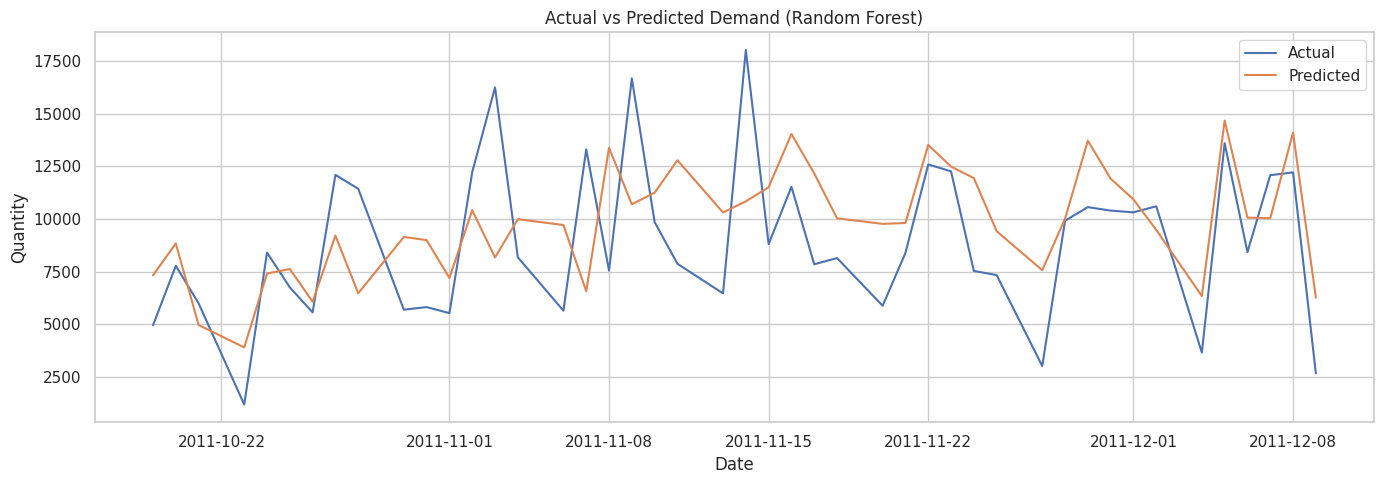

In [20]:
prediction_trend = (
    best_predictions
    .groupBy("OrderDate")
    .agg(
        F.sum("TotalQuantity").alias("ActualDemand"),
        F.sum("prediction").alias("PredictedDemand")
    )
    .orderBy("OrderDate")
    .toPandas()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=prediction_trend, x="OrderDate", y="ActualDemand", label="Actual")
sns.lineplot(data=prediction_trend, x="OrderDate", y="PredictedDemand", label="Predicted")
plt.title(f"Actual vs Predicted Demand ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "actual_vs_predicted_demand.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Big Data Engineer: Optimization and Performance

Spark optimization choices used in this notebook:

- `spark.sql.adaptive.enabled=true` allows Spark to adjust plans during execution.
- Cleaned data is written to HDFS as partitioned Parquet by `YearMonth`, which improves scan efficiency for time-based analysis.
- `repartition(8, "YearMonth")` distributes data before writing so partitions are less skewed locally.
- Frequently reused DataFrames such as `sales_df` and `feature_df` are cached after expensive transformations.
- A time-aware split avoids random leakage from future demand into training.

The local HDFS docker setup exposes the NameNode at `hdfs://localhost:9000` and the web UI at `http://localhost:9870`. In production, HDFS replication would be configured at the storage layer, commonly with replication factor 3 for fault tolerance.

In [21]:
print("sales_df partitions:", sales_df.rdd.getNumPartitions())
print("feature_df partitions:", feature_df.rdd.getNumPartitions())
feature_df.explain(mode="formatted")

sales_df partitions: 13
feature_df partitions: 8
== Physical Plan ==
AdaptiveSparkPlan (41)
+- == Final Plan ==
   ResultQueryStage (40)
   +- TableCacheQueryStage (39), Statistics(sizeInBytes=3.3 MiB, rowCount=3.49E+4)
      +- InMemoryTableScan (1)
            +- InMemoryRelation (2)
                  +- AdaptiveSparkPlan (38)
                  +- == Final Plan ==
                     ResultQueryStage (25)
                     +- * Filter (24)
                        +- Window (23)
                           +- * Sort (22)
                              +- ShuffleQueryStage (21), Statistics(sizeInBytes=4.4 MiB, rowCount=4.18E+4)
                                 +- Exchange (20)
                                    +- * Project (19)
                                       +- * HashAggregate (18)
                                          +- AQEShuffleRead (17)
                                             +- ShuffleQueryStage (16), Statistics(sizeInBytes=4.5 MiB, rowCount=5.94E+4)
        

## 5. MLOps Engineer: Deployment and Monitoring

Deployment plan:

- Schedule the ingestion, cleaning, feature engineering, and prediction steps as a daily Spark job.
- Load the saved pipeline model from `models/best_demand_forecasting_model` in the Streamlit deployment app.
- Write predictions to a data mart or dashboard table for inventory planning.
- Track model metrics after every retraining run in `outputs/model_metrics.csv` or an experiment tracker.

Monitoring plan:

- Monitor MAE/RMSE/R2 on the newest labeled period.
- Track data drift in product mix, country mix, average quantity, and missing-value rates.
- Retrain if error increases beyond an agreed threshold or if demand patterns change after holidays or campaigns.
- Alert the team when daily input row counts are unusually low or high.

In [22]:
monitoring_summary = (
    best_predictions
    .withColumn("AbsoluteError", F.abs(F.col("TotalQuantity") - F.col("prediction")))
    .agg(
        F.count("*").alias("PredictionRows"),
        F.round(F.avg("TotalQuantity"), 2).alias("AverageActualDemand"),
        F.round(F.avg("prediction"), 2).alias("AveragePredictedDemand"),
        F.round(F.avg("AbsoluteError"), 2).alias("AverageAbsoluteError"),
        F.min("OrderDate").alias("PredictionStartDate"),
        F.max("OrderDate").alias("PredictionEndDate"),
    )
)

monitoring_summary.toPandas().to_csv(OUTPUT_DIR / "monitoring_summary.csv", index=False)
monitoring_summary.show(truncate=False)

+--------------+-------------------+----------------------+--------------------+-------------------+-----------------+
|PredictionRows|AverageActualDemand|AveragePredictedDemand|AverageAbsoluteError|PredictionStartDate|PredictionEndDate|
+--------------+-------------------+----------------------+--------------------+-------------------+-----------------+
|6891          |58.25              |64.06                 |47.29               |2011-10-19         |2011-12-09       |
+--------------+-------------------+----------------------+--------------------+-------------------+-----------------+



## Final Conclusion

This project demonstrates a complete PySpark demand-forecasting workflow. The cleaned sales data is saved as Parquet, EDA identifies product and market demand patterns, historical lag features support forecasting, multiple Spark ML models are evaluated, and the best model is saved for repeatable use. The same design can be moved from local mode to a distributed Spark environment such as HDFS, Databricks, EMR, or another data lake platform.

Future improvements include tuning model hyperparameters, adding holiday/promotion features, filling missing product-date combinations for more regular time series, and connecting predictions to an inventory dashboard.